In [8]:
!pip install gdown pycocotools matplotlib seaborn opencv-python

import os

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)
print("DATA_DIR:", os.path.abspath(DATA_DIR))

DATA_DIR: /content/data


In [9]:
import gdown
import os

file_id = "1JfAa4Uw78kY1bwmZXdsd9azTy7y1kZC-"
url = f"https://drive.google.com/uc?id={file_id}"

anns_path = os.path.join("data", "annotations.json")
gdown.download(url, anns_path, quiet=False)

print("Downloaded annotations.json to:", os.path.abspath(anns_path))
print("Exists?", os.path.exists(anns_path))

Downloading...
From: https://drive.google.com/uc?id=1JfAa4Uw78kY1bwmZXdsd9azTy7y1kZC-
To: /content/data/annotations.json
100%|██████████| 3.02M/3.02M [00:00<00:00, 18.8MB/s]

Downloaded annotations.json to: /content/data/annotations.json
Exists? True


In [10]:
import os
import json
from PIL import Image
import requests
from io import BytesIO
import sys

DATASET_PATH = "./data/annotations.json"
dataset_dir = os.path.dirname(DATASET_PATH)

with open(DATASET_PATH, "r") as f:
    annotations = json.load(f)

nr_images = len(annotations["images"])
print("Number of images:", nr_images)

for i, image in enumerate(annotations["images"]):
    file_name = image["file_name"]
    url_original = image["flickr_url"]

    file_path = os.path.join(dataset_dir, file_name)
    subdir = os.path.dirname(file_path)
    os.makedirs(subdir, exist_ok=True)

    if not os.path.isfile(file_path):
        response = requests.get(url_original)
        img = Image.open(BytesIO(response.content))
        img.save(file_path)

    bar_size = 30
    x = int(bar_size * (i+1) / nr_images)
    sys.stdout.write("%s[%s%s] - %i/%i\r" %
                     ("Loading: ", "=" * x, "." * (bar_size - x), i+1, nr_images))
    sys.stdout.flush()

sys.stdout.write("\nFinished\n")

Number of images: 1500

Finished


10

In [11]:
import json

with open("data/annotations.json") as f:
    taco = json.load(f)

images = taco["images"]
annotations = taco["annotations"]
categories = taco["categories"]

print("num images:", len(images))
print("num annotations:", len(annotations))
print("num categories:", len(categories))

print("\nSample image entry:")
print(images[0])

print("\nSample annotation entry:")
print(annotations[0])

print("\nSample category entry:")
print(categories[0])

num images: 1500
num annotations: 4784
num categories: 60

Sample image entry:
{'id': 0, 'width': 1537, 'height': 2049, 'file_name': 'batch_1/000006.jpg', 'license': None, 'flickr_url': 'https://farm66.staticflickr.com/65535/33978196618_e30a59e0a8_o.png', 'coco_url': None, 'date_captured': None, 'flickr_640_url': 'https://farm66.staticflickr.com/65535/33978196618_632623b4fc_z.jpg'}

Sample annotation entry:
{'id': 1, 'image_id': 0, 'category_id': 6, 'segmentation': [[561.0, 1238.0, 568.0, 1201.0, 567.0, 1175.0, 549.0, 1127.0, 538.0, 1089.0, 519.0, 1043.0, 517.0, 1005.0, 523.0, 964.0, 529.0, 945.0, 520.0, 896.0, 525.0, 862.0, 536.0, 821.0, 554.0, 769.0, 577.0, 727.0, 595.0, 678.0, 596.0, 585.0, 588.0, 346.0, 581.0, 328.0, 569.0, 306.0, 570.0, 276.0, 576.0, 224.0, 560.0, 205.0, 564.0, 170.0, 578.0, 154.0, 608.0, 136.0, 649.0, 127.0, 688.0, 127.0, 726.0, 129.0, 759.0, 141.0, 784.0, 153.0, 792.0, 177.0, 788.0, 193.0, 782.0, 209.0, 792.0, 238.0, 802.0, 271.0, 802.0, 294.0, 791.0, 319.0, 789

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cat_id_to_name = {c["id"]: c["name"] for c in categories}
cat_id_to_super = {c["id"]: c.get("supercategory", "unknown") for c in categories}

ann_df = pd.DataFrame(annotations)

ann_df["category_name"] = ann_df["category_id"].map(cat_id_to_name)
ann_df["supercategory"] = ann_df["category_id"].map(cat_id_to_super)

print("Annotations DataFrame shape:", ann_df.shape)
ann_df.head()

# CHECK NaN / MISSING VALUES

print("\n=== Missing values per column in ann_df ===")
print(ann_df.isna().sum())

print("\n=== Rows that contain at least one NaN ===")
nan_rows = ann_df[ann_df.isna().any(axis=1)]
print("Number of rows with NaN:", len(nan_rows))

if len(nan_rows) > 0:
    display(nan_rows.head(10))
else:
    print("No NaN rows found in annotations DataFrame.")

important_cols = ["id", "image_id", "category_id", "bbox"]
print("\n=== Missing values in important columns ===")
for col in important_cols:
    if col in ann_df.columns:
        print(f"{col}: {ann_df[col].isna().sum()}")
    else:
        print(f"{col}: column not found")

# STRUCTURAL VALIDATION OF ANNOTATIONS

print("\n=== Structural checks on annotations ===")

# 2.1 category_id
valid_cat_ids = set(cat_id_to_name.keys())
invalid_cat_rows = ann_df[~ann_df["category_id"].isin(valid_cat_ids)]
print("Invalid category_id rows:", len(invalid_cat_rows))

if len(invalid_cat_rows) > 0:
    display(invalid_cat_rows.head())

# 2.2 image_id
valid_image_ids = set([img["id"] for img in images])
invalid_image_rows = ann_df[~ann_df["image_id"].isin(valid_image_ids)]
print("Invalid image_id rows:", len(invalid_image_rows))

if len(invalid_image_rows) > 0:
    display(invalid_image_rows.head())

# 2.3 bbox
def invalid_bbox(bbox):
    if not isinstance(bbox, list) or len(bbox) != 4:
        return True
    x, y, w, h = bbox
    if w is None or h is None:
        return True
    if w <= 0 or h <= 0:
        return True
    return False

invalid_bbox_rows = ann_df[ann_df["bbox"].apply(invalid_bbox)]
print("Invalid bbox rows:", len(invalid_bbox_rows))

if len(invalid_bbox_rows) > 0:
    display(invalid_bbox_rows.head())

# 2.4 category_name that are not map
unmapped_category_rows = ann_df[ann_df["category_name"].isna()]
print("Rows with unmapped category_name:", len(unmapped_category_rows))

if len(unmapped_category_rows) > 0:
    display(unmapped_category_rows.head())


ann_df.head()

Annotations DataFrame shape: (4784, 9)

=== Missing values per column in ann_df ===
id               0
image_id         0
category_id      0
segmentation     0
area             0
bbox             0
iscrowd          0
category_name    0
supercategory    0
dtype: int64

=== Rows that contain at least one NaN ===
Number of rows with NaN: 0
No NaN rows found in annotations DataFrame.

=== Missing values in important columns ===
id: 0
image_id: 0
category_id: 0
bbox: 0

=== Structural checks on annotations ===
Invalid category_id rows: 0
Invalid image_id rows: 0
Invalid bbox rows: 0
Rows with unmapped category_name: 0


,id,image_id,category_id,segmentation,area,bbox,iscrowd,category_name,supercategory
0,1,0,6,"[[561.0, 1238.0, 568.0, 1201.0, 567.0, 1175.0,...",403954.0,"[517.0, 127.0, 447.0, 1322.0]",0,Glass bottle,Bottle
1,2,1,18,"[[928.0, 1876.0, 938.0, 1856.0, 968.0, 1826.0,...",1071259.5,"[1.0, 457.0, 1429.0, 1519.0]",0,Meal carton,Carton
2,3,1,14,"[[617.0, 383.0, 703.0, 437.0, 713.0, 456.0, 72...",99583.5,"[531.0, 292.0, 1006.0, 672.0]",0,Other carton,Carton
3,4,2,5,"[[670.0, 993.0, 679.0, 998.0, 684.0, 1001.0, 6...",73832.5,"[632.0, 987.0, 500.0, 374.0]",0,Clear plastic bottle,Bottle
4,5,2,7,"[[647.0, 1028.0, 650.0, 1022.0, 653.0, 1016.0,...",915.0,"[632.0, 989.0, 44.0, 51.0]",0,Plastic bottle cap,Bottle cap


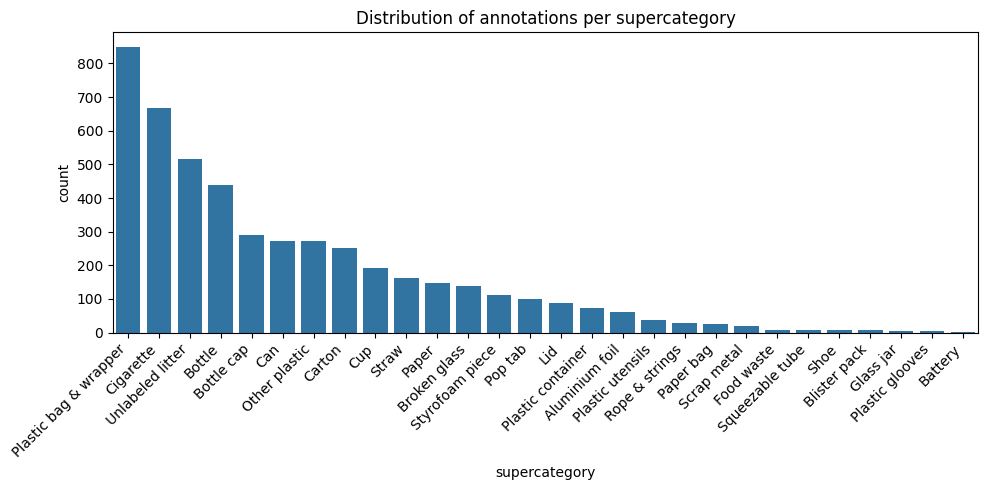

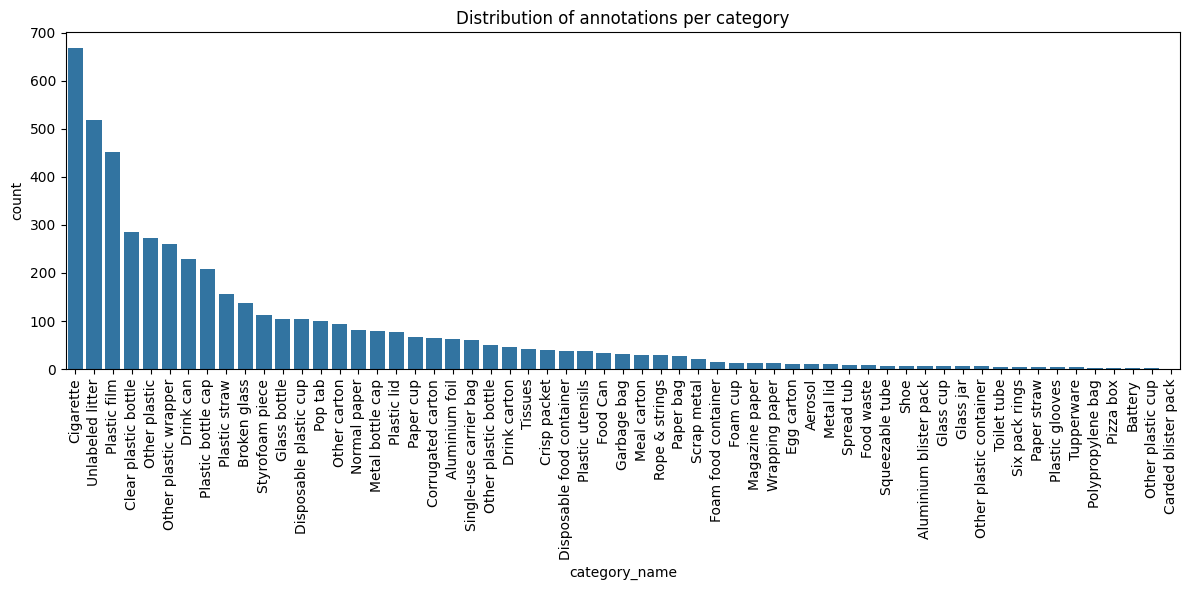

All categories (id, name, supercategory):


,id,name,supercategory
0,0,Aluminium foil,Aluminium foil
1,1,Battery,Battery
2,2,Aluminium blister pack,Blister pack
3,3,Carded blister pack,Blister pack
4,4,Other plastic bottle,Bottle
5,5,Clear plastic bottle,Bottle
6,6,Glass bottle,Bottle
7,7,Plastic bottle cap,Bottle cap
8,8,Metal bottle cap,Bottle cap
9,9,Broken glass,Broken glass



Categories used in annotations:


,id,name,supercategory
0,0,Aluminium foil,Aluminium foil
1,1,Battery,Battery
2,2,Aluminium blister pack,Blister pack
3,3,Carded blister pack,Blister pack
4,4,Other plastic bottle,Bottle
5,5,Clear plastic bottle,Bottle
6,6,Glass bottle,Bottle
7,7,Plastic bottle cap,Bottle cap
8,8,Metal bottle cap,Bottle cap
9,9,Broken glass,Broken glass



Category names (one per line):
- id= 0 | name=Aluminium foil | super=Aluminium foil
- id= 1 | name=Battery | super=Battery
- id= 2 | name=Aluminium blister pack | super=Blister pack
- id= 3 | name=Carded blister pack | super=Blister pack
- id= 4 | name=Other plastic bottle | super=Bottle
- id= 5 | name=Clear plastic bottle | super=Bottle
- id= 6 | name=Glass bottle | super=Bottle
- id= 7 | name=Plastic bottle cap | super=Bottle cap
- id= 8 | name=Metal bottle cap | super=Bottle cap
- id= 9 | name=Broken glass | super=Broken glass
- id=10 | name=Food Can | super=Can
- id=11 | name=Aerosol | super=Can
- id=12 | name=Drink can | super=Can
- id=13 | name=Toilet tube | super=Carton
- id=14 | name=Other carton | super=Carton
- id=15 | name=Egg carton | super=Carton
- id=16 | name=Drink carton | super=Carton
- id=17 | name=Corrugated carton | super=Carton
- id=18 | name=Meal carton | super=Carton
- id=19 | name=Pizza box | super=Carton
- id=20 | name=Paper cup | super=Cup
- id=21 | name=Disp

In [13]:
plt.figure(figsize=(10, 5))
sns.countplot(
    data=ann_df,
    x="supercategory",
    order=ann_df["supercategory"].value_counts().index
)
plt.xticks(rotation=45, ha="right")
plt.title("Distribution of annotations per supercategory")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.countplot(
    data=ann_df,
    x="category_name",
    order=ann_df["category_name"].value_counts().index
)
plt.xticks(rotation=90)
plt.title("Distribution of annotations per category")
plt.tight_layout()
plt.show()


cat_df = pd.DataFrame(categories)
print("All categories (id, name, supercategory):")
display(cat_df[["id", "name", "supercategory"]].sort_values("id"))

used_cat_ids = sorted(ann_df["category_id"].unique())
used_cat_df = cat_df[cat_df["id"].isin(used_cat_ids)]

print("\nCategories used in annotations:")
display(used_cat_df[["id", "name", "supercategory"]].sort_values("id"))

print("\nCategory names (one per line):")
for _, row in used_cat_df.sort_values("id").iterrows():
    print(f"- id={row['id']:2d} | name={row['name']} | super={row['supercategory']}")


In [14]:
recyclable = {
    "Aluminium foil",
    "Aluminium blister pack",
    "Carded blister pack",
    "Battery",
    "Other plastic bottle",
    "Clear plastic bottle",
    "Glass bottle",
    "Glass cup",
    "Plastic bottle cap",
    "Plastic film",
    "Metal bottle cap",
    "Food Can",
    "Aerosol",
    "Drink can",
    "Toilet tube",
    "Other carton",
    "Egg carton",
    "Drink carton",
    "Corrugated carton",
    "Meal carton",
    "Pizza box",
    "Magazine paper",
    "Wrapping paper",
    "Normal paper",
    "Paper bag",
    "Glass jar",
    "Metal lid",
    "Scrap metal",
    "Pop tab",
    "Polypropylene bag",
    "Plastic lid",
    "Spread tub",
    "Tupperware",
}
non_recyclable = {
    "Food waste",
    "Cigarette",
    "Broken glass",
    "Tissues",
    "Six pack rings",
    "Garbage bag",
    "Other plastic wrapper",
    "Single-use carrier bag",
    "Crisp packet",
    "Disposable plastic cup",
    "Foam cup",
    "Other plastic cup",
    "Foam food container",
    "Styrofoam piece",
    "Rope & strings",
    "Shoe",
    "Squeezable tube",
    "Plastic straw",
    "Paper straw",
    "Paper cup",
    "Plastic glooves",
    "Plastic utensils",
    "Other plastic",
    "Disposable food container",
    "Other plastic container",
}

CONF_THRESH_UNKNOWN = 0.35

def assign_recovery_bin(class_name: str, score: float) -> str:

    if score < CONF_THRESH_UNKNOWN:
        return "unknown"

    if class_name in recyclable:
        return "recyclable"
    elif class_name in non_recyclable:
        return "non_recyclable"
    else:
        return "unknown"

In [15]:
from pathlib import Path
from sklearn.model_selection import train_test_split

IMAGES_ROOT = Path("data")
images_by_id = {img["id"]: img for img in images}

image_id_to_batch = {}

for img_id, img_rec in images_by_id.items():
    file_name = img_rec["file_name"]
    batch_name = Path(file_name).parts[0]
    image_id_to_batch[img_id] = batch_name

batches = sorted(set(image_id_to_batch.values()))
print("Total batches:", len(batches))
print(batches[:15])

train_batches, temp_batches = train_test_split(
    batches, test_size=0.30, random_state=42
)
val_batches, test_batches = train_test_split(
    temp_batches, test_size=0.50, random_state=42
)

print("Train batches:", train_batches)
print("Val batches:", val_batches)
print("Test batches:", test_batches)

train_image_ids = []
val_image_ids = []
test_image_ids = []

for img_id, batch_name in image_id_to_batch.items():
    if batch_name in train_batches:
        train_image_ids.append(img_id)
    elif batch_name in val_batches:
        val_image_ids.append(img_id)
    elif batch_name in test_batches:
        test_image_ids.append(img_id)

print("Train images:", len(train_image_ids))
print("Val images:", len(val_image_ids))
print("Test images:", len(test_image_ids))

def make_coco_subset(selected_image_ids, all_data):
    imgs = {img["id"]: img for img in all_data["images"]}

    subset_images = [imgs[i] for i in selected_image_ids]
    subset_image_id_set = set(selected_image_ids)

    subset_annotations = [
        ann for ann in all_data["annotations"]
        if ann["image_id"] in subset_image_id_set
    ]

    subset = {
        "info": all_data.get("info", {}),
        "licenses": all_data.get("licenses", []),
        "categories": all_data.get("categories", []),
        "images": subset_images,
        "annotations": subset_annotations,
    }
    return subset

train_data = make_coco_subset(train_image_ids, taco)
val_data   = make_coco_subset(val_image_ids, taco)
test_data  = make_coco_subset(test_image_ids, taco)

print("Train annotations:", len(train_data["annotations"]))
print("Val annotations:", len(val_data["annotations"]))
print("Test annotations:", len(test_data["annotations"]))

Total batches: 15
['batch_1', 'batch_10', 'batch_11', 'batch_12', 'batch_13', 'batch_14', 'batch_15', 'batch_2', 'batch_3', 'batch_4', 'batch_5', 'batch_6', 'batch_7', 'batch_8', 'batch_9']
Train batches: ['batch_3', 'batch_11', 'batch_10', 'batch_9', 'batch_13', 'batch_2', 'batch_5', 'batch_7', 'batch_12', 'batch_15']
Val batches: ['batch_4', 'batch_8']
Test batches: ['batch_6', 'batch_14', 'batch_1']
Train images: 1013
Val images: 189
Test images: 298
Train annotations: 3291
Val annotations: 597
Test annotations: 896


In [16]:
import json
from pathlib import Path

def save_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

save_json(train_data, "data/splits/annotations_train.json")
save_json(val_data,   "data/splits/annotations_val.json")
save_json(test_data,  "data/splits/annotations_test.json")

print("All subset JSON files saved successfully.")


All subset JSON files saved successfully.


In [17]:
s_train = set(train_image_ids)
s_val = set(val_image_ids)
s_test = set(test_image_ids)

print("train ∩ val:", len(s_train & s_val))
print("train ∩ test:", len(s_train & s_test))
print("val ∩ test:", len(s_val & s_test))

assert s_train.isdisjoint(s_val)
assert s_train.isdisjoint(s_test)
assert s_val.isdisjoint(s_test)

print("No overlap between splits")

train ∩ val: 0
train ∩ test: 0
val ∩ test: 0
No overlap between splits


In [18]:
import json
import shutil
from pathlib import Path

# Config
COCO_SPLITS = {
    "train": Path("data/splits/annotations_train.json"),
    "val":   Path("data/splits/annotations_val.json"),
    "test":  Path("data/splits/annotations_test.json"),
}

IMAGES_ROOT = Path("data")
OUT_ROOT    = Path("taco_yolo")

COPY_IMAGES = True

def coco_bbox_to_yolo(bbox, img_w, img_h):
    # COCO bbox: [x_min, y_min, w, h] (pixels)
    x, y, w, h = bbox
    x_c = x + w / 2.0
    y_c = y + h / 2.0
    # normalize
    return (x_c / img_w, y_c / img_h, w / img_w, h / img_h)

def clamp01(v):
    return max(0.0, min(1.0, v))

def ensure_dir(p: Path):
    p.mkdir(parents=True, exist_ok=True)

# Determining used categories and create mapping
used_cat_ids = set()
all_categories_by_id = {}

with open(COCO_SPLITS["train"], "r", encoding="utf-8") as f:
    coco_tmp = json.load(f)
for c in coco_tmp["categories"]:
    all_categories_by_id[c["id"]] = c

for split, p in COCO_SPLITS.items():
    with open(p, "r", encoding="utf-8") as f:
        coco = json.load(f)
    for ann in coco["annotations"]:
        used_cat_ids.add(ann["category_id"])

used_cat_ids = sorted(used_cat_ids)
cat_id_to_yolo = {cat_id: i for i, cat_id in enumerate(used_cat_ids)}
names = [all_categories_by_id[cid]["name"] for cid in used_cat_ids]

print("nc =", len(names))
print("first classes:", names[:10])

# Creating folder structure
for split in ["train", "val", "test"]:
    ensure_dir(OUT_ROOT / "images" / split)
    ensure_dir(OUT_ROOT / "labels" / split)

# Converting each split
for split, ann_path in COCO_SPLITS.items():
    with open(ann_path, "r", encoding="utf-8") as f:
        coco = json.load(f)

    images = coco["images"]
    anns   = coco["annotations"]

    anns_by_image = {}
    for ann in anns:
        anns_by_image.setdefault(ann["image_id"], []).append(ann)

    # process images
    for img in images:
        img_id = img["id"]
        file_name = img["file_name"]
        img_w = img["width"]
        img_h = img["height"]

        src_img = IMAGES_ROOT / file_name
        p = Path(file_name)
        dst_name = f"{p.parts[0]}__{p.name}"
        dst_img = OUT_ROOT / "images" / split / dst_name
        dst_lbl = OUT_ROOT / "labels" / split / (Path(dst_name).stem + ".txt")


        if COPY_IMAGES:
            if not dst_img.exists():
                shutil.copy2(src_img, dst_img)
        else:
            if not dst_img.exists():
                dst_img.symlink_to(src_img.resolve())

        lines = []
        for ann in anns_by_image.get(img_id, []):
            if ann.get("iscrowd", 0) == 1:
                continue

            cat_id = ann["category_id"]
            if cat_id not in cat_id_to_yolo:
                continue

            yolo_cls = cat_id_to_yolo[cat_id]
            x_c, y_c, w, h = coco_bbox_to_yolo(ann["bbox"], img_w, img_h)

            x_c = clamp01(x_c); y_c = clamp01(y_c)
            w   = clamp01(w);   h   = clamp01(h)

            if w <= 0 or h <= 0:
                continue

            lines.append(f"{yolo_cls} {x_c:.6f} {y_c:.6f} {w:.6f} {h:.6f}")

        dst_lbl.write_text("\n".join(lines) + ("\n" if lines else ""), encoding="utf-8")

    print(f"[{split}] images={len(images)} anns={len(anns)} done.")

# Writing data.yaml
yaml_text = (
    f"path: {OUT_ROOT.resolve()}\n"
    f"train: images/train\n"
    f"val: images/val\n"
    f"test: images/test\n\n"
    f"nc: {len(names)}\n"
    f"names:\n"
)

for n in names:
    yaml_text += f"  - {n!r}\n"

(OUT_ROOT / "data.yaml").write_text(yaml_text, encoding="utf-8")
print("Wrote:", OUT_ROOT / "data.yaml")

nc = 59
first classes: ['Aluminium foil', 'Battery', 'Aluminium blister pack', 'Carded blister pack', 'Other plastic bottle', 'Clear plastic bottle', 'Glass bottle', 'Plastic bottle cap', 'Metal bottle cap', 'Broken glass']
[train] images=1013 anns=3291 done.
[val] images=189 anns=597 done.
[test] images=298 anns=896 done.
Wrote: taco_yolo/data.yaml


In [19]:
from pathlib import Path

label_files = sorted(Path("taco_yolo/labels/train").glob("*.txt"))
print("Total label files:", len(label_files))

for f in label_files[:5]:
    text = f.read_text().strip()
    print("\n---", f.name, "---")
    print(text[:300] if text else "[EMPTY LABEL FILE]")

Total label files: 1013

--- batch_10__000000.txt ---
5 0.855263 0.341500 0.208333 0.037500

--- batch_10__000001.txt ---
4 0.119000 0.164500 0.114500 0.218202
7 0.071375 0.253316 0.019250 0.038377
57 0.099125 0.076232 0.050750 0.070175
57 0.270500 0.461649 0.106500 0.135965
57 0.236625 0.462745 0.047750 0.101974
53 0.590625 0.514829 0.065750 0.112939
57 0.619613 0.507702 0.020750 0.058114
5 0.665274 0.270037 0.042000 

--- batch_10__000002.txt ---
57 0.175250 0.316064 0.029000 0.027961
29 0.078750 0.767544 0.029000 0.015351
5 0.356750 0.599781 0.101500 0.109649
7 0.310125 0.645559 0.008250 0.020285
57 0.321625 0.251371 0.034750 0.032346
35 0.014500 0.400219 0.025500 0.044956

--- batch_10__000003.txt ---
35 0.012500 0.154057 0.024500 0.046053
5 0.160000 0.255482 0.062000 0.097588
5 0.196875 0.223958 0.061250 0.104715
35 0.139250 0.210526 0.034500 0.048246
35 0.109500 0.104715 0.019500 0.038377
38 0.195500 0.351700 0.016500 0.037829
21 0.295000 0.487664 0.025000 0.055373
57 0.415750 0.

In [20]:
from pathlib import Path

label_dirs = [
    Path("taco_yolo/labels/train"),
    Path("taco_yolo/labels/val"),
    Path("taco_yolo/labels/test"),
]

bad_files = []
bad_lines = []
total_files = 0
total_lines = 0
empty_files = 0

for d in label_dirs:
    for f in d.glob("*.txt"):
        total_files += 1
        text = f.read_text().strip()

        if not text:
            empty_files += 1
            continue

        lines = text.splitlines()
        for i, line in enumerate(lines, start=1):
            total_lines += 1
            parts = line.strip().split()

            if len(parts) != 5:
                bad_lines.append((str(f), i, line, f"expected 5 values, got {len(parts)}"))
                bad_files.append(str(f))
                continue

            try:
                cls_id = int(parts[0])
                x, y, w, h = map(float, parts[1:])
            except Exception as e:
                bad_lines.append((str(f), i, line, f"parse error: {e}"))
                bad_files.append(str(f))
                continue

            if not (0 <= cls_id <= 58):
                bad_lines.append((str(f), i, line, f"class_id out of range: {cls_id}"))
                bad_files.append(str(f))

            for name, val in zip(["x", "y", "w", "h"], [x, y, w, h]):
                if not (0.0 <= val <= 1.0):
                    bad_lines.append((str(f), i, line, f"{name} out of range: {val}"))
                    bad_files.append(str(f))

            if w <= 0 or h <= 0:
                bad_lines.append((str(f), i, line, f"degenerate bbox: w={w}, h={h}"))
                bad_files.append(str(f))

bad_files = sorted(set(bad_files))

print("Total files:", total_files)
print("Empty files:", empty_files)
print("Total non-empty label lines checked:", total_lines)
print("Files with issues:", len(bad_files))
print("Bad lines:", len(bad_lines))

print("\nFirst 20 bad lines:")
for item in bad_lines[:20]:
    print(item)

Total files: 1500
Empty files: 0
Total non-empty label lines checked: 4784
Files with issues: 0
Bad lines: 0

First 20 bad lines:


In [21]:
!pip install -q ultralytics

from ultralytics import YOLO

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 38.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [22]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")

model.train(
    data="taco_yolo/data.yaml",
    epochs=35,
    imgsz=640,
    batch=16,
    patience=10,
    workers=2,
    device=0,
    project="runs/taco",
    name="yolov8s_640",
    mosaic=1.0,
    close_mosaic=10,
    erasing=0.1,
)

Ultralytics 8.4.110 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=taco_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=35, erasing=0.1, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_640, nbs=64, nms=False, opset=Non

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  4,  5,  6,  7,  8,  9, 10, 12, 14, 15, 16, 17, 20, 21, 24, 25, 27, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 44, 46, 47, 49, 50, 51, 53, 54, 56, 57, 58])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ff37c07b770>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036

In [36]:
import os
import yaml
from collections import defaultdict

import numpy as np
from ultralytics import YOLO
from PIL import Image, ImageDraw, ImageFont

MODEL_PATH = "runs/detect/runs/taco/yolov8s_640/weights/best.pt"
DATA_CONFIG_PATH = "taco_yolo/data.yaml"
CONF_THRESHOLD = 0.25
IOU_THRESHOLD = 0.5
NUM_VISUALIZE = 10


def load_data_config(yaml_path):
    with open(yaml_path, "r") as f:
        data = yaml.safe_load(f)
    return data


# IoU
def compute_iou(box1, box2):
    """
    box = [x1, y1, x2, y2]
    """
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter_w = max(0, x2 - x1)
    inter_h = max(0, y2 - y1)
    inter_area = inter_w * inter_h

    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])

    union_area = area1 + area2 - inter_area
    if union_area == 0:
        return 0.0
    return inter_area / union_area


# detection
def visualize_results(model, test_images, class_names, save_dir="test_vis"):
    os.makedirs(save_dir, exist_ok=True)

    subset = test_images[:NUM_VISUALIZE]

    for img_path in subset:
        results = model(img_path, conf=CONF_THRESHOLD)
        res = results[0]

        im = Image.open(img_path).convert("RGB")
        draw = ImageDraw.Draw(im)

        font = ImageFont.load_default()

        for box in res.boxes:
            cls_id = int(box.cls[0])
            conf = float(box.conf[0])
            class_name = class_names[cls_id]

            # bbox: xyxy
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            draw.rectangle([x1, y1, x2, y2], outline="red", width=2)

            text = f"{class_name} ({conf:.2f})"
            bbox = draw.textbbox((x1, y1), text, font=font)
            text_w = bbox[2] - bbox[0]
            text_h = bbox[3] - bbox[1]
            tx1 = x1
            ty1 = max(0, y1 - text_h)
            tx2 = x1 + text_w
            ty2 = y1
            draw.rectangle([tx1, ty1, tx2, ty2], fill="red")
            draw.text((tx1, ty1), text, fill="white", font=font)

        save_path = os.path.join(save_dir, os.path.basename(img_path))
        im.save(save_path)
        print(f"[VIS] Saved visualization: {save_path}")


def load_yolo_labels(label_path):
    boxes = []
    if not os.path.exists(label_path):
        return boxes

    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()
        if len(parts) != 5:
            continue
        cls_id = int(parts[0])
        cx, cy, w, h = map(float, parts[1:])

        boxes.append((cls_id, cx, cy, w, h))

    return boxes


def yolo_to_xyxy(yolo_boxes, img_width, img_height):
    converted = []
    for cls_id, cx, cy, w, h in yolo_boxes:
        cx *= img_width
        cy *= img_height
        w *= img_width
        h *= img_height

        x1 = cx - w / 2
        y1 = cy - h / 2
        x2 = cx + w / 2
        y2 = cy + h / 2

        converted.append({
            "cls_id": cls_id,
            "bbox": [x1, y1, x2, y2]
        })
    return converted


# test
def evaluate_on_test():
    print("[INFO] Loading model...")
    model = YOLO(MODEL_PATH)

    print("[INFO] Loading data config...")
    data_cfg = load_data_config(DATA_CONFIG_PATH)
    base_dir = os.path.dirname(DATA_CONFIG_PATH)
    test_rel = data_cfg.get("test", "images/test")
    test_dir = os.path.join(base_dir, test_rel)

    class_names = data_cfg["names"]
    num_classes = len(class_names)

    print(f"[INFO] Test directory: {test_dir}")
    print(f"[INFO] Number of classes: {num_classes}")

    test_images = []
    for fname in os.listdir(test_dir):
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
            test_images.append(os.path.join(test_dir, fname))

    test_images = sorted(test_images)
    print(f"[INFO] Found {len(test_images)} test images.")

    if len(test_images) == 0:
        print("[ERROR] No test images found. Check your 'test' path in YAML.")
        return

    # Visualize
    print("[INFO] Visualizing some test images...")
    visualize_results(model, test_images, class_names)

    #TP/FP/FN per-class
    tp = np.zeros(num_classes, dtype=np.int64)
    fp = np.zeros(num_classes, dtype=np.int64)
    fn = np.zeros(num_classes, dtype=np.int64)

    print("[INFO] Running evaluation on test set...")

    for img_path in test_images:
        base_dir = os.path.dirname(test_dir)
        ds_root = os.path.dirname(base_dir)
        rel = os.path.relpath(img_path, ds_root)
        # rel: images/test/XXX.jpg
        label_rel = rel.replace("images", "labels").rsplit(".", 1)[0] + ".txt"
        label_path = os.path.join(ds_root, label_rel)

        img = Image.open(img_path).convert("RGB")
        img_w, img_h = img.size

        gt_yolo = load_yolo_labels(label_path)
        gt_boxes = yolo_to_xyxy(gt_yolo, img_w, img_h)

        results = model(img_path, conf=CONF_THRESHOLD)
        res = results[0]

        pred_boxes = []
        for box in res.boxes:
            cls_id = int(box.cls[0])
            conf = float(box.conf[0])
            if conf < CONF_THRESHOLD:
                continue
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            pred_boxes.append({
                "cls_id": cls_id,
                "bbox": [x1, y1, x2, y2],
                "conf": conf
            })


        gt_used = [False] * len(gt_boxes)

        for pred in pred_boxes:
            pred_cls = pred["cls_id"]
            pred_box = pred["bbox"]

            best_iou = 0.0
            best_gt_idx = -1

            for idx, gt in enumerate(gt_boxes):
                if gt_used[idx]:
                    continue
                if gt["cls_id"] != pred_cls:
                    continue

                iou = compute_iou(pred_box, gt["bbox"])
                if iou > best_iou:
                    best_iou = iou
                    best_gt_idx = idx

            if best_iou >= IOU_THRESHOLD and best_gt_idx != -1:
                # TP
                tp[pred_cls] += 1
                gt_used[best_gt_idx] = True
            else:
                # FP
                fp[pred_cls] += 1

        # FN
        for idx, gt in enumerate(gt_boxes):
            if not gt_used[idx]:
                gt_cls = gt["cls_id"]
                fn[gt_cls] += 1

    # Precision/Recall per-class
    print("\n========== Per-class Evaluation (IoU >= {:.2f}) ==========".format(IOU_THRESHOLD))
    print("{:<3} {:<30} {:>8} {:>8} {:>8} {:>10} {:>10}".format(
        "ID", "Class", "TP", "FP", "FN", "Precision", "Recall"
    ))
    print("-" * 80)

    for cid in range(num_classes):
        tp_c = tp[cid]
        fp_c = fp[cid]
        fn_c = fn[cid]

        precision_c = tp_c / (tp_c + fp_c) if (tp_c + fp_c) > 0 else 0.0
        recall_c = tp_c / (tp_c + fn_c) if (tp_c + fn_c) > 0 else 0.0

        print("{:<3} {:<30} {:>8} {:>8} {:>8} {:>10.3f} {:>10.3f}".format(
            cid, class_names[cid], tp_c, fp_c, fn_c, precision_c, recall_c
        ))

    # overall
    total_tp = tp.sum()
    total_fp = fp.sum()
    total_fn = fn.sum()

    overall_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
    overall_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0.0

    print("\n========== Overall ==========")
    print(f"Total TP: {total_tp}")
    print(f"Total FP: {total_fp}")
    print(f"Total FN: {total_fn}")
    print(f"Overall Precision: {overall_precision:.3f}")
    print(f"Overall Recall   : {overall_recall:.3f}")


if __name__ == "__main__":
    evaluate_on_test()


[INFO] Loading model...
[INFO] Loading data config...
[INFO] Test directory: taco_yolo/images/test
[INFO] Number of classes: 59
[INFO] Found 298 test images.
[INFO] Visualizing some test images...

image 1/1 /content/taco_yolo/images/test/batch_14__000000.jpg: 480x640 1 Garbage bag, 12.8ms
Speed: 3.3ms preprocess, 12.8ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)
[VIS] Saved visualization: test_vis/batch_14__000000.jpg

image 1/1 /content/taco_yolo/images/test/batch_14__000001.jpg: 480x640 1 Disposable plastic cup, 12.9ms
Speed: 3.2ms preprocess, 12.9ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)
[VIS] Saved visualization: test_vis/batch_14__000001.jpg

image 1/1 /content/taco_yolo/images/test/batch_14__000002.jpg: 480x640 (no detections), 25.6ms
Speed: 10.7ms preprocess, 25.6ms inference, 3.1ms postprocess per image at shape (1, 3, 480, 640)
[VIS] Saved visualization: test_vis/batch_14__000002.jpg

image 1/1 /content/taco_yolo/images/test/bat